In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import os
from matplotlib import pyplot as plt
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
from scipy.interpolate import interp1d,PchipInterpolator
import kuibit.simdir as SD
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import glob
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov
import pickle
from Modules.eos_bar_analytic import EOS_Piecewise_Poly
import bisect
from PyCompose.compose.eos import Metadata,Table 


In [3]:
#Physical Constants
c = 299792458  # Speed of light in m/s
G = 6.67430e-11  # Gravitational constant in m^3/kg/s^2
hc = 197.3 #hbar c Mev fm

freq_code_u_to_hz = 203000
mn = 939.56
n0 = 0.16
epsilon = mn*n0
kg_m3_to_MeV_fm3 = 5.605*10**(-16)
Pa_to_MeV_fm3 = 6.242*10**(-33)
R0 = 1.477 #Solar Mass to km conversion

geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3

geometrized_code_to_nb_n0 = (((geometrized_to_SI*(1/1476)**2)*kg_to_g/m3_to_cm3)/(1.6582*10**(-24)))*(1/(10**39))


In [4]:
p_central = np.logspace(-2,np.log10(5),100)

In [5]:
def fit_model(k2T,a0,a1,a2,a3,a4):
    return a0*((1.0 + a1*k2T + a2*(k2T**2))/(1.0 + a3*k2T + a4*(k2T**2)))

In [6]:
EOS_V = rvss_eos(1200,mu_max=2700)
EOS_IV = rvss_eos(1300,mu_max=2700)
EOS_III = rvss_eos(1400,mu_max=2700)
EOS_II = rvss_eos(1500,mu_max=2700)
EOS_I = rvss_eos(1700,mu_max=2700)

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [7]:
RVSS_cs2p_interp = {}
RVSS_cs2_interp = {}
mu_idx_V = bisect.bisect_right(EOS_V.chem_pot_unified,980)
mu_fit_V = EOS_V.chem_pot_unified[mu_idx_V:]

mu_idx_IV = bisect.bisect_right(EOS_IV.chem_pot_unified,980)
mu_fit_IV = EOS_V.chem_pot_unified[mu_idx_IV:]

mu_idx_III = bisect.bisect_right(EOS_III.chem_pot_unified,980)
mu_fit_III = EOS_V.chem_pot_unified[mu_idx_III:]

mu_idx_II = bisect.bisect_right(EOS_II.chem_pot_unified,980)
mu_fit_II = EOS_II.chem_pot_unified[mu_idx_II:]

mu_idx_I = bisect.bisect_right(EOS_I.chem_pot_unified,980)
mu_fit_I = EOS_I.chem_pot_unified[mu_idx_I:]


EOS_V_cs2p = np.gradient(EOS_V.cs2_unified[mu_idx_V:],EOS_V.chem_pot_unified[mu_idx_V:])
EOS_IV_cs2p = np.gradient(EOS_IV.cs2_unified[mu_idx_IV:],EOS_IV.chem_pot_unified[mu_idx_IV:])
EOS_III_cs2p = np.gradient(EOS_III.cs2_unified[mu_idx_III:],EOS_III.chem_pot_unified[mu_idx_III:])
EOS_II_cs2p = np.gradient(EOS_II.cs2_unified[mu_idx_II:],EOS_II.chem_pot_unified[mu_idx_II:])
EOS_I_cs2p = np.gradient(EOS_I.cs2_unified[mu_idx_I:],EOS_I.chem_pot_unified[mu_idx_I:])



RVSS_cs2p_interp["V"] = interp1d(EOS_V.P_unified[mu_idx_V:],EOS_V_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["IV"] = interp1d(EOS_IV.P_unified[mu_idx_IV:],EOS_IV_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["III"] = interp1d(EOS_III.P_unified[mu_idx_III:],EOS_III_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["II"] = interp1d(EOS_II.P_unified[mu_idx_II:],EOS_II_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["I"] = interp1d(EOS_I.P_unified[mu_idx_I:],EOS_I_cs2p,fill_value='extrapolate')




In [8]:
solve_I = tov(epsilon,lambda p: EOS_I.eos_interp(p*epsilon)/epsilon,lambda p: EOS_I.nb_interp(p*epsilon),lambda p: EOS_I.cs2_interp(p*epsilon))
solve_II = tov(epsilon,lambda p: EOS_II.eos_interp(p*epsilon)/epsilon,lambda p: EOS_II.nb_interp(p*epsilon),lambda p: EOS_II.cs2_interp(p*epsilon))
solve_III = tov(epsilon,lambda p: EOS_III.eos_interp(p*epsilon)/epsilon,lambda p: EOS_III.nb_interp(p*epsilon),lambda p: EOS_III.cs2_interp(p*epsilon))
solve_IV = tov(epsilon,lambda p: EOS_IV.eos_interp(p*epsilon)/epsilon,lambda p: EOS_IV.nb_interp(p*epsilon),lambda p: EOS_IV.cs2_interp(p*epsilon))
solve_V = tov(epsilon,lambda p: EOS_V.eos_interp(p*epsilon)/epsilon,lambda p: EOS_V.nb_interp(p*epsilon),lambda p: EOS_V.cs2_interp(p*epsilon))

RVSS_Solver_list = {"I":solve_I,
                    "II": solve_II,
                    "III": solve_III,
                    "IV": solve_IV,
                    "V": solve_V}

In [9]:
eos_colors = {"BA": "red",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "DD2F": "slategray",
              "BLh": "darkgreen",
              "LS220": "plum",
              }

core_subeos = {
              "DD2": "brown",
              "BHBlp": "green",
              "BLQ": "purple",
              "BLh": "black",
              "LS220": "red"}


In [49]:
p_central = np.logspace(-2,np.log10(5),100)

In [10]:

RVSS_List = {"V" : [EOS_V,'red',0.0039],  
             "IV" : [EOS_IV,'purple',0.0027],
             "III" : [EOS_III,'blue',0.0021],
             "II": [EOS_II,'green',0.0017],
             "I": [EOS_I,'black',0.0012]}   

In [11]:
RVSS_f2_list_1p4 = np.asarray([2.3183139534883717, 2.935739436619718, 0.7318230115361263, 0.7441348973607038])
RVSS_f2_list_1p3 = np.asarray([2.2601524758454103, 2.837993421052632, 3.1352294608472397, 0.71104410331384, 2.5674536256323774])
RVSS_f2_list_1p35 = np.asarray([2.640295504994450315e+00])
cs2p_1p4_list = np.asarray([RVSS_List['V'][2],RVSS_List['III'][2],RVSS_List['II'][2],RVSS_List['I'][2]])
cs2p_1p3_list = np.asarray([RVSS_List['V'][2],RVSS_List['III'][2],RVSS_List['II'][2],RVSS_List['I'][2],RVSS_List['IV'][2]])
cs2p_1p35_list = np.asanyarray([RVSS_List['IV'][2],])

RVSS_Mf2_list_1p3 = (2.6)*(RVSS_f2_list_1p3)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p4 = (2.8)*(RVSS_f2_list_1p4)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p35 = (2.7)*(RVSS_f2_list_1p35)*1000/freq_code_u_to_hz


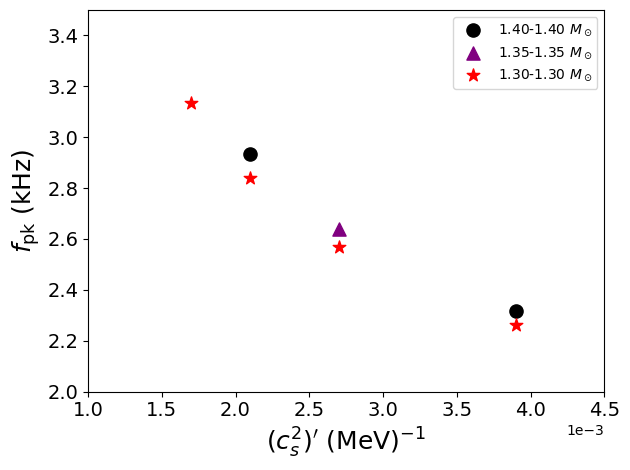

In [12]:
axes_label_fontsize = 18
tick_label_fontsize = 14
text_fontsize = 22
point_size = 90

fpk_fig,fpk_axes = plt.subplots(1)

fpk_axes.scatter(cs2p_1p4_list,RVSS_f2_list_1p4,s=point_size,color='black',marker='o',label=r'1.40-1.40 $M_\odot$')
fpk_axes.scatter(cs2p_1p35_list,RVSS_f2_list_1p35,s=point_size,color='purple',marker='^',label=r'1.35-1.35 $M_\odot$')
fpk_axes.scatter(cs2p_1p3_list,RVSS_f2_list_1p3,s=point_size,color='red',marker='*',label=r'1.30-1.30 $M_\odot$')

fpk_axes.set_ylim([2.0,3.5])
fpk_axes.set_xlim([0.001,0.0045])
fpk_axes.set_xlabel(r"$(c_s^2)'\text{ (MeV)}^{-1}$",fontsize=axes_label_fontsize)
fpk_axes.set_ylabel(r"$f_{\text{pk}}\text{ (kHz)}$",fontsize=axes_label_fontsize)
fpk_axes.legend()
fpk_axes.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
fpk_axes.tick_params(labelsize=tick_label_fontsize)
fpk_fig.tight_layout()
# fpk_fig.savefig('./Figures/Final_Paper_Figs/f2pk_vs_cs2p.pdf',format='pdf',dpi=300)


In [13]:
core_mvr_data = {}
core_m_cs2_mub_Vavg_interp = {}
core_M_pcentral_interp = {}
core_M_R_interp = {}
max_mass_core = {}


for file in os.listdir('./MVR/CORE'):
    file_split = file.split("_")
    eos = file_split[0]
    mvr_data = np.loadtxt(f'./MVR/CORE/{file}',skiprows=1)
    core_mvr_data[eos] = mvr_data
    core_m_cs2_mub_Vavg_interp[eos] = interp1d(mvr_data[:,0],mvr_data[:,6])
    core_M_pcentral_interp[eos] = interp1d(mvr_data[:,0],p_central)
    core_M_R_interp[eos] = interp1d(core_mvr_data[eos][:,0],core_mvr_data[eos][:,1])
    max_mass_core[eos] = max(mvr_data[:,0])



In [14]:
rvss_mvr_data = {}
rvss_M_pcentral_interp = {}
rvss_m_cs2_mub_Vavg_interp = {}
rvss_M_R_interp = {}

for file in os.listdir('./MVR/RVSS'):
    file_split = file.split('_')
    model = file_split[0]
    rvss_mvr_data[model] = np.loadtxt(f'./MVR/RVSS/{file}',skiprows=1)
    rvss_M_pcentral_interp[model] = interp1d(rvss_mvr_data[model][:,0],p_central)
    rvss_M_R_interp[model] = interp1d(rvss_mvr_data[model][:,0],rvss_mvr_data[model][:,1])
    rvss_m_cs2_mub_Vavg_interp[model] = interp1d(rvss_mvr_data[model][:,0],rvss_mvr_data[model][:,5])

In [15]:
eos_V_M_pr_interp = interp1d(rvss_mvr_data["V"][:,0],p_central)
eos_IV_M_pr_interp = interp1d(rvss_mvr_data["IV"][:,0],p_central)
eos_III_M_pr_interp = interp1d(rvss_mvr_data["III"][:,0],p_central)
eos_II_M_pr_interp = interp1d(rvss_mvr_data["II"][:,0],p_central)
eos_I_M_pr_interp = interp1d(rvss_mvr_data["I"][:,0],p_central)

In [16]:
eos_V_p_1p3 = eos_V_M_pr_interp(1.3)
eos_IV_p_1p3 = eos_IV_M_pr_interp(1.3)
eos_III_p_1p3 = eos_III_M_pr_interp(1.3)
eos_II_p_1p3 = eos_II_M_pr_interp(1.3)
eos_I_p_1p3 = eos_I_M_pr_interp(1.3)

eos_V_p_1p4 = eos_V_M_pr_interp(1.4)
eos_IV_p_1p4 = eos_IV_M_pr_interp(1.4)
eos_III_p_1p4 = eos_III_M_pr_interp(1.4)
eos_II_p_1p4 = eos_II_M_pr_interp(1.4)
eos_I_p_1p4 = eos_I_M_pr_interp(1.4)

eos_IV_p_1p35 = eos_IV_M_pr_interp(1.35)



In [17]:
def kappa2T(L):
    return (3/16)*L

In [18]:
eos_V_1p3_lambda,eos_V_1p3_k2 = solve_V.solve_tidal(eos_V_p_1p3)
eos_IV_1p3_lambda,eos_IV_1p3_k2 = solve_IV.solve_tidal(eos_IV_p_1p3)
eos_III_1p3_lambda,eos_III_1p3_k2 = solve_III.solve_tidal(eos_III_p_1p3)
eos_II_1p3_lambda,eos_II_1p3_k2 = solve_II.solve_tidal(eos_II_p_1p3)
eos_I_1p3_lambda,eos_I_1p3_k2 = solve_I.solve_tidal(eos_I_p_1p3)

eos_V_1p4_lambda,eos_V_1p4_k2 = solve_V.solve_tidal(eos_V_p_1p4)
eos_IV_1p4_lambda,eos_IV_1p4_k2 = solve_IV.solve_tidal(eos_IV_p_1p4)
eos_III_1p4_lambda,eos_III_1p4_k2 = solve_III.solve_tidal(eos_III_p_1p4)
eos_II_1p4_lambda,eos_II_1p4_k2 = solve_II.solve_tidal(eos_II_p_1p4)
eos_I_1p4_lambda,eos_I_1p4_k2 = solve_I.solve_tidal(eos_I_p_1p4)

eos_IV_1p35_lambda,eos_IV_1p35_k2 = solve_IV.solve_tidal(eos_IV_p_1p35)

eos_I_kappa2T_1p3 = kappa2T(eos_I_1p3_lambda)
eos_II_kappa2T_1p3 = kappa2T(eos_II_1p3_lambda)
eos_III_kappa2T_1p3 = kappa2T(eos_III_1p3_lambda)
eos_IV_kappa2T_1p3 = kappa2T(eos_IV_1p3_lambda)
eos_V_kappa2T_1p3 = kappa2T(eos_V_1p3_lambda)

eos_I_kappa2T_1p4 = kappa2T(eos_I_1p4_lambda)
eos_II_kappa2T_1p4 = kappa2T(eos_II_1p4_lambda)
eos_III_kappa2T_1p4 = kappa2T(eos_III_1p4_lambda)
eos_IV_kappa2T_1p4 = kappa2T(eos_IV_1p4_lambda)
eos_V_kappa2T_1p4 = kappa2T(eos_V_1p4_lambda)

eos_IV_kappa2T_1p35 = kappa2T(eos_IV_1p35_lambda)



In [19]:
core_db_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB'
core_db_eos_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB/EOS'
sim_names = [name for name in os.listdir(core_db_path) if os.path.isdir(os.path.join(core_db_path,name)) and (name != 'EOS' and name != 'SkyNet')]
eos_list = [name for name in os.listdir(core_db_eos_path) if os.path.isdir(os.path.join(core_db_eos_path,name))]
sim_dirs = {}

sim_info = {}

for sim in sim_names:
    sim_info[sim] = {}
    sim_name_parsed = sim.split('_')
    eos_name = sim_name_parsed[0]
    mass_1 = float(sim_name_parsed[1])
    mass_2 = float(sim_name_parsed[2])
    mass_total = mass_1 + mass_2

    sim_info[sim]['m1'] = mass_1
    sim_info[sim]['m2'] = mass_2

    sim_info[sim]['m_total'] = mass_total
    sim_info[sim]['eos'] = eos_name

 
    
    metadata = os.path.abspath(os.path.join(core_db_path,sim,'metadata.txt'))
    with open(metadata,'r') as file:
        lines = file.readlines()
        for line in lines:
            line = line.strip('\n')
            line_split = line.split(' ')
            line_split = [x for x in line_split if x]
            if len(line_split) > 0:
                if line_split[0] == 'id_kappa2T':
                    sim_info[sim]["kappa_2T"] = float(line_split[-1])
                if line_split[0] == 'id_Lambda':
                    sim_info[sim]["Lambda_2T"] = float(line_split[-1])
                if line_split[0] == 'id_spin_starA':
                    sim_info[sim]["spin1"] = [float(line_split[-3].strip(',')),float(line_split[-2].strip(',')),float(line_split[-1].strip(','))]
    

In [23]:
print(sim_info)

{'DD2_1.497_1.245_0.00_0.00_0.024_0.167_M0': {'m1': 1.497, 'm2': 1.245, 'm_total': 2.742, 'eos': 'DD2', 'kappa_2T': 150.51957333030552, 'Lambda_2T': 801.1040321390645, 'spin1': [0.0, 0.0, 0.0]}, 'SFHo_1.452_1.283_0.00_0.00_0.024_0.083_M0_LK': {'m1': 1.452, 'm2': 1.283, 'm_total': 2.735, 'eos': 'SFHo', 'kappa_2T': 74.02788896626019, 'Lambda_2T': 394.26064420510033, 'spin1': [0.0, 0.0, 0.0]}, 'SLy4_1.856_1.020_0.00_0.00_0.051_0.167_M0_LK': {'m1': 1.856, 'm2': 1.02, 'm_total': 2.8760000000000003, 'eos': 'SLy4', 'kappa_2T': 68.76228069651988, 'Lambda_2T': 356.96455952751677, 'spin1': [0.0, 0.0, 0.0]}, 'LS220_1.200_1.200_0.00_0.00_0.047_0.125': {'m1': 1.2, 'm2': 1.2, 'm_total': 2.4, 'eos': 'LS220', 'kappa_2T': 269.8160807630395, 'Lambda_2T': 1439.0190974028765, 'spin1': [0.0, 0.0, 0.0]}, 'BLh_1.300_1.300_0.00_0.00_0.053_0.167_M0': {'m1': 1.3, 'm2': 1.3, 'm_total': 2.6, 'eos': 'BLh', 'kappa_2T': 130.20652272977892, 'Lambda_2T': 694.4347878921542, 'spin1': [0.0, 0.0, 0.0]}, 'LS220_1.350_1.350

In [20]:
eos_cs2 = {}
eos_eden = {}
eos_press = {}
eos_dens = {}
eos_mub = {}
eos_cs2p = {}
eos_dnde = {}

eos_interp = {}
dens_interp = {}
cs2p_interp = {}
eos_mub_interp = {}
eos_cs2_interp = {}
eos_cs2_dens_interp = {}
cs2p_dens_interp = {}

for eos_name in eos_list:
    if os.path.isdir(os.path.join(core_db_eos_path,eos_name)):
        pizza_files = glob.glob(os.path.join(core_db_eos_path,eos_name,'*.pizza'))
        with open(pizza_files[0]) as eos_file:
            eos_data = np.loadtxt(eos_file,skiprows=5)
            if(eos_data.shape[0] == 3): continue
            else:
                eos_dens[eos_name] = eos_data[:,0] * kg_m3_to_MeV_fm3 * (1/mn)
                eos_cs2[eos_name] = eos_data[:,3]
                eos_eden[eos_name] = (eos_data[:,1] + 1) * mn * eos_dens[eos_name]
                eos_press[eos_name] = eos_data[:,2] * Pa_to_MeV_fm3
                eos_mub[eos_name] = (eos_eden[eos_name] + eos_press[eos_name])/(eos_dens[eos_name])
    
    idx_mustart = bisect.bisect_right(eos_mub[eos_name],970)

    eos_cs2_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_cs2[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_cs2p[eos_name] = np.gradient(eos_cs2[eos_name],eos_mub[eos_name])
    eos_dnde[eos_name] = np.gradient(eos_dens[eos_name],eos_eden[eos_name])
    eos_interp[eos_name] = PchipInterpolator(eos_press[eos_name][idx_mustart:],eos_eden[eos_name][idx_mustart:])
    dens_interp[eos_name] = PchipInterpolator(eos_press[eos_name][idx_mustart:],eos_dens[eos_name][idx_mustart:])
    

    cs2p_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_cs2p[eos_name][idx_mustart:],fill_value='extrapolate')
    cs2p_dens_interp[eos_name] = interp1d(eos_dens[eos_name][idx_mustart:],eos_cs2p[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_mub_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_mub[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_cs2_dens_interp[eos_name] = interp1d(eos_dens[eos_name],eos_cs2[eos_name],fill_value='extrapolate')

def create_solver(eos_i, epsilon):
    return tov(
        epsilon,
        eos = lambda p: eos_interp[eos_i](p * epsilon) / epsilon,
        bary_density= lambda p: dens_interp[eos_i](p * epsilon),
        dpde=lambda p: eos_cs2_interp[eos_i](p* epsilon)
    )

solver_list = {eos_i : create_solver(eos_i, epsilon) for eos_i in eos_interp.keys()}

In [21]:
core_muTOV = {}
for eos in max_mass_core:
    pc = core_M_pcentral_interp[eos](max_mass_core[eos])
    core_muTOV[eos] = eos_mub_interp[eos](pc*epsilon)

In [22]:
core_cs2p_interp = {}
for file in os.listdir('./Core_EOS_Interpreters'):
    file_split = file.split('_')
    eos = file_split[0]
    with open (f'./Core_EOS_Interpreters/{file}','rb') as pkl_file:
        core_cs2p_interp[eos] = pickle.load(pkl_file)
        print(eos)

SLy
SLy4
BLQ
BHBlp
LS220
MS1b
BA
DD2F-SF1
BLh
DD2
SFHo
DD2F


In [23]:
core_cs2p_Vavg_M = {}
core_cs2p_Vavg_M_r = {}
core_M_r = {}

for eos in solver_list:
    if eos in core_subeos:
        core_cs2p_Vavg_M[eos] = np.empty_like(p_central)
        core_M_r[eos] = np.empty_like(p_central)
        print(eos)
        for i,pc in enumerate(p_central):
            sol,nu,dpdr = solver_list[eos].solve_nu(pc)
            n_r = dens_interp[eos](sol.y[0,:]*epsilon)
            n_c = dens_interp[eos](sol.y[0,0]*epsilon)
            
            R = sol.t[-1]
            
            
            cs2p_r = core_cs2p_interp[eos](sol.y[0,:]*epsilon)
            cs2p_r_interp = interp1d(sol.t,cs2p_r,fill_value='extrapolate')
            NS_nb_r_interp = interp1d(n_r,sol.t,fill_value='extrapolate')
            r_stop = NS_nb_r_interp((2.0/3.0)*n_c)

            idx_rstop = bisect.bisect_right(sol.t,r_stop)

            M_r = sol.y[1,:idx_rstop]
            r_grid = sol.t[:idx_rstop]
            nu = nu[:idx_rstop]
            cs2p_r = cs2p_r[:idx_rstop]
            print(len(nu[:idx_rstop]),len(M_r))
            if len(nu[:idx_rstop]) != len(M_r):
                if len(nu[:idx_rstop]) < len(M_r):
                    M_r = M_r[:len(nu)]
                    r_grid = r_grid[:len(nu)]
                    cs2p_r = cs2p_r[:len(nu)]
                else:
                    nu = nu[:len(M_r)]
                    M_r = M_r[:len(M_r)]
                    r_grid = r_grid[:len(M_r)]
                    cs2p_r = cs2p_r[:len(M_r)]
            
            Vol,cs2p_Vavg = solver_list[eos].ns_vol_avg(cs2p_r,r_grid,M_r,solution=sol,nu_sol=nu)

            core_cs2p_Vavg_M[eos][i] = cs2p_Vavg[-1]
            core_M_r[eos][i] = sol.y[1,-1]

            

DD2
-0.02721654737091067 -0.027216547370910667
583 583
-0.028220088937243554 -0.02822008893724355
582 582
-0.02932592362632671 -0.02932592362632671
582 582
-0.030419871749737447 -0.030419871749737447
583 583
-0.03158894361315171 -0.031588943613151704
585 585
-0.032782726009355896 -0.032782726009355896
588 588
-0.03402262859366731 -0.03402262859366731
592 592
-0.03531146537208502 -0.03531146537208502
596 596
-0.03665128185151324 -0.03665128185151324
601 601
-0.03802346884286247 -0.03802346884286248
607 607
-0.03949404453995708 -0.039494044539957085
613 613
-0.041002665250111786 -0.04100266525011179
620 620
-0.04256813879703402 -0.04256813879703402
627 627
-0.04422015323270199 -0.044220153232701995
634 634
-0.04589775103621098 -0.04589775103621097
642 642
-0.047675682010281356 -0.04767568201028135
649 649
-0.049529133164192066 -0.049529133164192066
657 657
-0.05148780893123083 -0.05148780893123083
665 665
-0.05350433287727826 -0.05350433287727826
673 673
-0.055605200717454846 -0.05560520

KeyboardInterrupt: 

In [ ]:
RVSS_cs2p_Vavg_M = {}
RVSS_cs2p_Vavg_M_r = {}
RVSS_M_r = {}

for model in RVSS_Solver_list:
    RVSS_cs2p_Vavg_M[model] = np.empty_like(p_central)
    RVSS_M_r[model] = np.empty_like(p_central)
    print(model)
    for i,pc in enumerate(p_central):
        sol,nu,index = RVSS_Solver_list[model].solve_nu(pc)
        n_r = RVSS_List[model][0].nb_interp(sol.y[0,:]*epsilon)
        n_c = RVSS_List[model][0].nb_interp(sol.y[0,0]*epsilon)
        
        R = sol.t[-1]
        
        
        cs2p_r = RVSS_cs2p_interp[model](sol.y[0,:]*epsilon)
        cs2p_r_interp = interp1d(sol.t,cs2p_r,fill_value='extrapolate')
        NS_nb_r_interp = interp1d(n_r,sol.t,fill_value='extrapolate')
        r_stop = NS_nb_r_interp((2.0/3.0)*n_c)

        idx_rstop = bisect.bisect_right(sol.t,r_stop)

        M_r = sol.y[1,:idx_rstop]
        r_grid = sol.t[:idx_rstop]
        nu = nu[:idx_rstop]
        cs2p_r = cs2p_r[:idx_rstop]
        if len(nu[:idx_rstop]) != len(M_r):
            if len(nu[:idx_rstop]) < len(M_r):
                M_r = M_r[:len(nu)]
                r_grid = r_grid[:len(nu)]
                cs2p_r = cs2p_r[:len(nu)]
            else:
                nu = nu[:len(M_r)]
                M_r = M_r[:len(M_r)]
                r_grid = r_grid[:len(M_r)]
                cs2p_r = cs2p_r[:len(M_r)]
        
        Vol,cs2p_Vavg = RVSS_Solver_list[model].ns_vol_avg(cs2p_r,r_grid,M_r,solution=sol,nu_sol=nu)
        print(i)
        RVSS_cs2p_Vavg_M[model][i] = cs2p_Vavg[-1]
        RVSS_M_r[model][i] = sol.y[1,-1]

I
-0.010488974797807143 -0.010488974797807145
0
-0.01142163405963496 -0.011421634059634957
1
-0.012392407596860052 -0.012392407596860049
2
-0.013403147741687731 -0.01340314774168773
3
-0.014457881713911977 -0.014457881713911977
4
-0.015549574571697176 -0.015549574571697172
5
-0.016693477485783523 -0.016693477485783523
6
-0.017878170552508132 -0.017878170552508135
7
-0.019110420264707405 -0.019110420264707405
8
-0.020387383417728163 -0.020387383417728167
9
-0.021719055303773056 -0.021719055303773056
10
-0.023108177580341786 -0.023108177580341782
11
-0.024544951228903537 -0.024544951228903544
12
-0.02603374666875103 -0.026033746668751023
13
-0.027578856741783623 -0.02757885674178362
14
-0.02915908163331313 -0.029159081633313128
15
-0.03079504756793538 -0.030795047567935385
16
-0.03248112877477851 -0.0324811287747785
17
-0.034220939335981755 -0.034220939335981755
18
-0.03601166000036268 -0.03601166000036269
19
-0.037855145047532596 -0.037855145047532596
20
-0.03976135263901274 -0.03976135

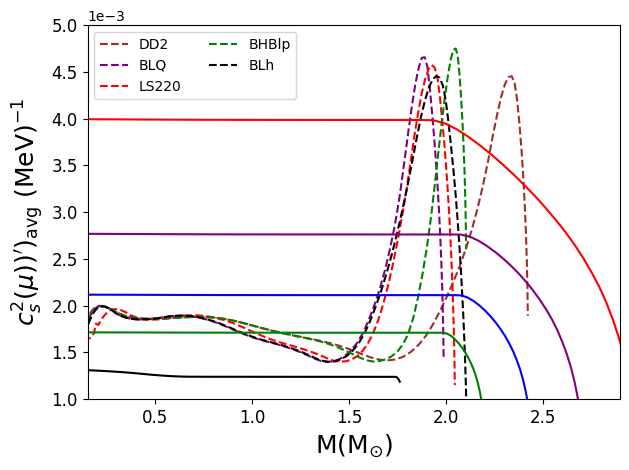

In [52]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 20
cs2p_vavg_m_fig,cs2p_vavg_m_axes = plt.subplots(1)

for eos in core_cs2p_Vavg_M:
    idx_stop = np.argmax(core_M_r[eos])
    cs2p_vavg_m_axes.plot(core_M_r[eos][:idx_stop],core_cs2p_Vavg_M[eos][:idx_stop],color=core_subeos[eos],label=eos,linestyle='--')

for model in RVSS_cs2p_Vavg_M:
    idx_stop = np.argmax(RVSS_M_r[model])
    cs2p_vavg_m_axes.plot(RVSS_M_r[model][:idx_stop],RVSS_cs2p_Vavg_M[model][:idx_stop],color=RVSS_List[model][1])

cs2p_vavg_m_axes.set_ylim([0.001,0.005])
cs2p_vavg_m_axes.set_xlim([0.15,2.9])

cs2p_vavg_m_axes.set_xlabel(r"$\text{M(M}_{\odot})$",fontsize=axes_label_fontsize)
cs2p_vavg_m_axes.set_ylabel(r"$c_s^2(\mu))')_{\text{avg}}\text{ (MeV)}^{-1}$",fontsize=axes_label_fontsize)
cs2p_vavg_m_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_vavg_m_axes.ticklabel_format(style='sci',scilimits=(-3,3),axis='y')
cs2p_vavg_m_axes.legend(ncols=2)
cs2p_vavg_m_fig.tight_layout()
# cs2p_vavg_m_fig.savefig('./Figures/Final_Paper_Figs/cs2p_Vavg_M.pdf',format='pdf',dpi=300)



In [ ]:
dd2_cs2p_M_interp = interp1d(core_M_r['DD2'],core_cs2p_Vavg_M['DD2'])


In [92]:
print(dd2_cs2p_M_interp(1.2))

print(dd2_cs2p_M_interp(1.654))

0.0016861149204031904
0.0014249155593735888


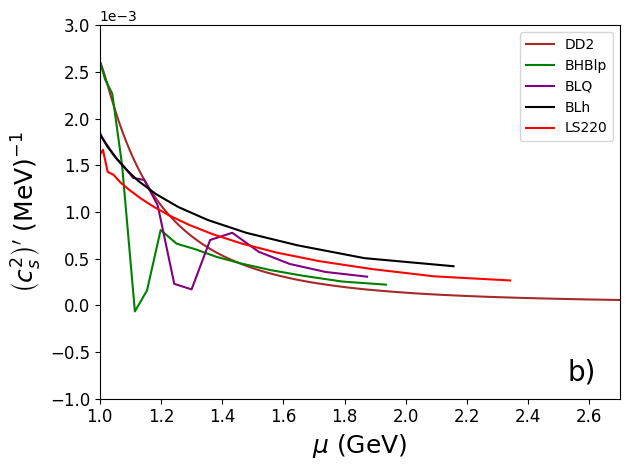

In [21]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 20

cs2p_mub_fig,cs2p_mub_axes = plt.subplots(1)
for eos_name in core_subeos:
    cs2p_mub_axes.plot(eos_mub[eos_name]/1000,eos_cs2p[eos_name],color=core_subeos[eos_name],label=eos_name)
    cs2p_mub_axes.set_xlim([1.0,2.7])
    cs2p_mub_axes.set_ylim([-0.001,0.003])
    
    # cs2p_mub_axes.axhline(RVSS_List["I"][2],color = RVSS_List["I"][1],linestyle='--')
    # cs2p_mub_axes.axhline(RVSS_List["II"][2],color = RVSS_List["II"][1],linestyle='--')
    # cs2p_mub_axes.axhline(RVSS_List["III"][2],color = RVSS_List["III"][1],linestyle='--')
    # cs2p_mub_axes.axhline(RVSS_List["IV"][2],color = RVSS_List["IV"][1],linestyle='--')
    # cs2p_mub_axes.axhline(RVSS_List["V"][2],color = RVSS_List["V"][1],linestyle='--')
    #plt.axvline(core_muTOV[eos_name]/1000,color=core_subeos[eos_name])
cs2p_mub_axes.set_xlabel(r"$\mu\text{ (GeV)}$",fontsize=axes_label_fontsize)
cs2p_mub_axes.set_ylabel(r"$\left(c_s^2\right)'\text{ (MeV)}^{-1}$",fontsize=axes_label_fontsize)
cs2p_mub_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mub_axes.ticklabel_format(style='sci',axis='y',scilimits=(-3.0,-3.0))
cs2p_mub_axes.text(0.9,0.05,'b)',transform=cs2p_mub_axes.transAxes,fontsize=text_fontsize)
cs2p_mub_axes.legend()
cs2p_mub_fig.tight_layout()
# cs2p_mub_fig.savefig('./Figures/Final_Paper_Figs/cs2p_mub.pdf',format='pdf',dpi=300)
    


In [34]:
mu_max_V = 1235.0
mu_max_IV = 1308.0
mu_max_III = 1441.0
mu_max_II = 1494.0

In [35]:
eos_V_max_idx = bisect.bisect_left(EOS_V.chem_pot_unified,mu_max_V)
eos_IV_max_idx = bisect.bisect_left(EOS_IV.chem_pot_unified,mu_max_IV)
eos_III_max_idx = bisect.bisect_left(EOS_III.chem_pot_unified,mu_max_III)
eos_II_max_idx = bisect.bisect_left(EOS_II.chem_pot_unified,mu_max_II)


In [36]:
max_indices = {'V': eos_V_max_idx,
               'IV': eos_IV_max_idx,
               'III': eos_III_max_idx,
               'II':eos_II_max_idx,
               'I': len(EOS_I.chem_pot_unified)}

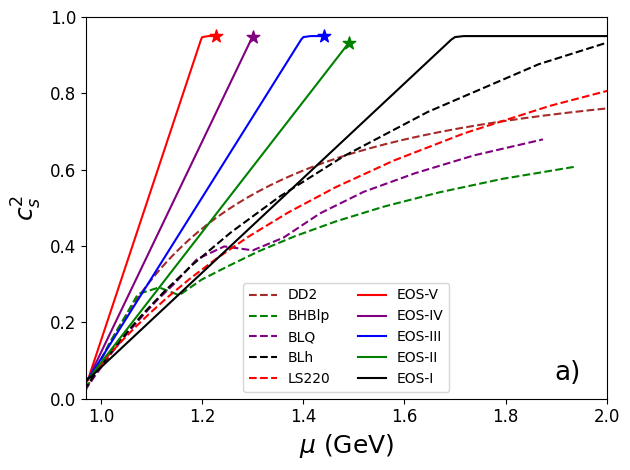

In [37]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 19
cs2_mub_fig,cs2_mub_axes = plt.subplots(1)
for eos_name in core_subeos:
    cs2_mub_axes.plot(eos_mub[eos_name]/1000,eos_cs2[eos_name],color=core_subeos[eos_name],linestyle='--',label=eos_name)
    cs2_mub_axes.set_xlabel(r"$\mu\text{ (GeV)}$")
for model in RVSS_List:
    eos = RVSS_List[model][0]
    max_idx = max_indices[model]
    cs2_mub_axes.plot(eos.chem_pot_unified[:max_idx]/1000,eos.cs2_unified[:max_idx],color = RVSS_List[model][1],label=f'EOS-{model}')
    cs2_mub_axes.scatter([eos.chem_pot_unified[max_idx-1]/1000,],[eos.cs2_unified[max_idx-1],],marker='*',color = RVSS_List[model][1],s=90)

cs2_mub_axes.set_xlim([0.970,2.0])
cs2_mub_axes.set_ylim([0.0,1.0])

cs2_mub_axes.set_xlabel(r"$\mu\text{ (GeV)}$",fontsize=axes_label_fontsize)
cs2_mub_axes.set_ylabel(r"$c_s^2$",fontsize=axes_label_fontsize)
cs2_mub_axes.tick_params(labelsize=tick_label_fontsize)
cs2_mub_axes.text(0.9,0.05,'a)',transform=cs2_mub_axes.transAxes,fontsize=text_fontsize)
cs2_mub_axes.legend(ncols=2)
cs2_mub_fig.tight_layout()
cs2_mub_fig.savefig('./Figures/Final_Paper_Figs/cs2_mub.pdf',format='pdf',dpi=300)

 

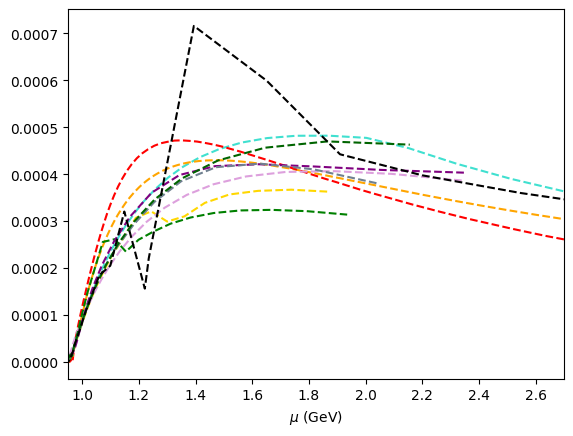

In [23]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 20

cs2mub_mub_fig,cs2mub_mub_axes = plt.subplots(1)
for eos_name in eos_cs2:
    cs2mub_mub_axes.plot(eos_mub[eos_name]/1000,eos_cs2[eos_name]/eos_mub[eos_name],color=eos_colors[eos_name],linestyle='--')
    cs2mub_mub_axes.set_xlim([0.950,2.700])
    cs2mub_mub_axes.set_xlabel(r"$\mu\text{ (GeV)}$")
#for model in RVSS_List:
    #eos = RVSS_List[model][0]
    #cs2_mub_axes.plot(eos.chem_pot_unified/1000,eos.cs2_unified,color = RVSS_List[model][1],label=f'EOS-{model}')

cs2p_mub_fig.tight_layout()
# cs2p_mub_fig.savefig('./Figures/Final_Paper_Figs/cs2p_mub.pdf',format='pdf',dpi=300)

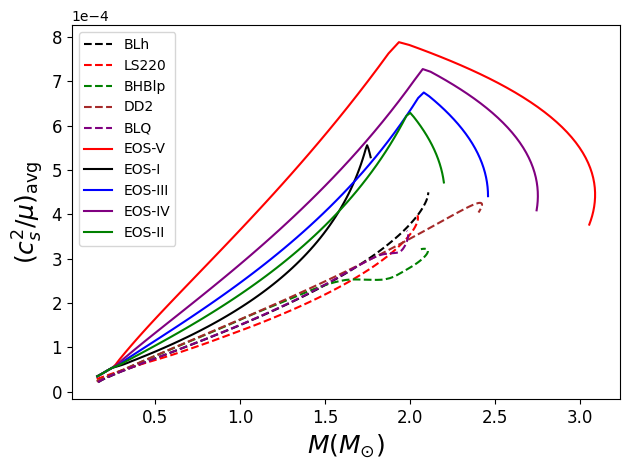

In [24]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16
cs2_mub_m_fig,cs2_mub_m_axes = plt.subplots(1)
for eos in core_mvr_data:
    if eos in core_subeos:
        data = core_mvr_data[eos]
        M = data[:,0]
        R = data[:,1]
        cs2_mub_Vavg = data[:,6]
        mub_cs2p_Vavg = data[:,7]
        cs2_mub_m_axes.plot(M,cs2_mub_Vavg,color=core_subeos[eos],label=eos,linestyle = '--')
for model in rvss_mvr_data:
    data_RVSS = rvss_mvr_data[model]
    M = data_RVSS[:,0]
    R = data_RVSS[:,1]
    cs2_mub_Vavg = data_RVSS[:,5]
    mub_cs2p_Vavg = data_RVSS[:,6]
    cs2_mub_m_axes.plot(M,cs2_mub_Vavg,label=f'EOS-{model}',color=RVSS_List[model][1])
cs2_mub_m_axes.legend()
cs2_mub_m_axes.set_xlabel(r'$M(M_{\odot})$',fontsize=axes_label_fontsize)
cs2_mub_m_axes.set_ylabel(r'$(c_s^2/\mu)_{\text{avg}}$',fontsize=axes_label_fontsize)
cs2_mub_m_axes.tick_params(labelsize=tick_label_fontsize)
cs2_mub_m_axes.ticklabel_format(style='sci',axis='y',scilimits=(-4.0,-4.0))
cs2_mub_m_fig.tight_layout()
#cs2_mub_m_fig.savefig('./Figures/Final_Paper_Figs/cs2_mu_avg_M.pdf',format='pdf',dpi=300)




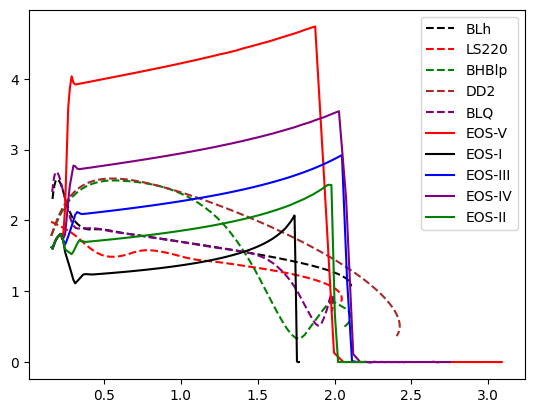

In [25]:
cs2p_mub_fig,csp_mub_axes = plt.subplots()
for eos in core_mvr_data:
    if eos in core_subeos:
        data = core_mvr_data[eos]
        M = data[:,0]
        R = data[:,1]
        mub_cs2p_Vavg = data[:,7]
        csp_mub_axes.plot(M,mub_cs2p_Vavg,color=core_subeos[eos],linestyle = '--',label=eos)
for model in rvss_mvr_data:
    data_RVSS = rvss_mvr_data[model]
    M = data_RVSS[:,0]
    R = data_RVSS[:,1]
    mub_cs2p_Vavg = data_RVSS[:,6]
    csp_mub_axes.plot(M,mub_cs2p_Vavg,color=RVSS_List[model][1],label=f"EOS-{model}")
csp_mub_axes.legend()



In [24]:
kb_sim_dirs = {}

for eos in sim_names:
    kb_sim_dirs[eos] = SD.SimDir(os.path.abspath(os.path.join(core_db_path,eos)))
p_cut = 600

core_db_strain = {}
core_db_gws = {}
core_db_gw_phase = {}
core_db_gw_inst_freq = {}
core_db_gw_asd = {}
core_db_gw_htilde = {}

core_fpeak = {}

for sim_name in kb_sim_dirs:
    sd = kb_sim_dirs[sim_name]
    core_db_strain[sim_name] = {}
    core_db_gws[sim_name] = {}
    for gw in sd.gws:
        extr_radius = str(gw.radius)
        core_db_gws[sim_name][extr_radius] = gw
        strain = gw.get_strain_lm(2,
                                2,
                                p_cut,
                                0.1,
                                window_function='tukey')
        core_db_strain[sim_name][extr_radius] = strain

for sim in core_db_strain:
    core_db_gw_phase[sim] = {}
    core_db_gw_inst_freq[sim] = {}
    for r in core_db_strain[sim]:
        time = core_db_strain[sim][r].t
        real_h = np.real(core_db_strain[sim][r].y)
        imag_h = np.imag(core_db_strain[sim][r].y)
        phase = np.unwrap(np.arctan2(real_h,imag_h))
        
        core_db_gw_phase[sim][r] = phase
        core_db_gw_inst_freq[sim][r] = (1/(2*np.pi))*np.gradient(phase,time)
    
    core_db_gw_asd[sim] = {}
    core_db_gw_htilde[sim] = {}
    for r in core_db_strain[sim]:
        h_plus = core_db_strain[sim][r].real()
        h_cross = core_db_strain[sim][r].imag()

        h_plus_tilde = h_plus.to_FrequencySeries()
        h_cross_tilde = h_cross.to_FrequencySeries()

        h_tilde = np.sqrt((h_plus_tilde.real()**2 + h_plus_tilde.imag()**2) + (h_cross_tilde.real()**2 + h_cross_tilde.imag()**2))
        core_db_gw_htilde[sim][r] = h_tilde
        core_db_gw_asd[sim][r] = 2.0*h_tilde.fft*np.sqrt(h_tilde.f*freq_code_u_to_hz)
    core_fpeak[sim] = core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])]*freq_code_u_to_hz/1000
    sim_info[sim]['Mfpeak'] = (core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])])*(sim_info[sim]['m_total'])
    sim_info[sim]['fpeak'] = core_fpeak[sim]


<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0

/home/john/.local/lib/python3.10/site-packages/kuibit/timeseries.py:769: RuntimeWarning: TimeSeries is not regularly samples. Resampling.
  warnings.warn(


<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0x7e7f47fac4c0>
<function tukey at 0

In [25]:
sim_info_core_subeos = {}
i = 0
for sim in sim_info:
    if sim_info[sim]['eos'] in core_subeos and sim_info[sim]['m1'] == sim_info[sim]['m2'] and sim_info[sim]['spin1'] == [0.0,0.0,0.0]  and sim_info[sim]['Mfpeak'] > 0.02:
        
        sim_info_core_subeos[sim] = sim_info[sim]

       

        if os.path.exists(core_db_path+"/"+sim+"/diagnostics/rho.maximum.asc"):
            rho_max_data = np.loadtxt(core_db_path+"/"+sim+"/diagnostics/rho.maximum.asc")
            rho = rho_max_data[:,2]*geometrized_code_to_nb_n0
            sim_info_core_subeos[sim]['rho_max'] = max(rho)
            if max(rho) > max(eos_dens[sim_info[sim]['eos']]):
                sim_info_core_subeos[sim]['rho_max'] = max(eos_dens[sim_info[sim]['eos']])
        #sim_info_core_subeos[sim]['cs2mub_Vavg'] = float(core_m_cs2_mub_Vavg_interp[sim_info[sim]['eos']](sim_info[sim]['m1']))
        p_central = core_M_pcentral_interp[sim_info[sim]['eos']](sim_info[sim]['m1'])
        solution,nu,dpdr = solver_list[sim_info[sim]['eos']].solve_nu(p_central)
        n_r = dens_interp[sim_info[sim]['eos']](solution.y[0,:]*epsilon)
        n_c = dens_interp[sim_info[sim]['eos']](solution.y[0,0]*epsilon)
        mass = sim_info[sim]['m1']
        R = solution.t[-1]
        M = solution.y[1,-1]
        # rho_max = sim_info[sim]['rho_max']
        # print(rho_max)
        
        R_1p6 = core_M_R_interp[sim_info[sim]['eos']](1.6)
        R_1p4 = core_M_R_interp[sim_info[sim]['eos']](1.4)
        sim_info[sim]['C'] = (M*R0)/R
        sim_info[sim]['C1p6'] = (1.6*R0)/R_1p6
        sim_info[sim]['C1p4'] = (1.4*R0)/R_1p4

        # sim_info[sim]['cs2_max'] = eos_cs2_dens_interp[sim_info[sim]['eos']](sim_info[sim]['rho_max'])
        
        NS_nb_r_interp = interp1d(n_r,solution.t,fill_value='extrapolate')

        cs2p_r = core_cs2p_interp[sim_info[sim]['eos']](solution.y[0,:]*epsilon)
        r_stop = NS_nb_r_interp((2.0/3.0)*n_c)

        idx_rstop = bisect.bisect_right(solution.t,r_stop)
 
     
        Vol,cs2p_Vavg = solver_list[sim_info[sim]['eos']].ns_vol_avg(cs2p_r[:idx_rstop],solution.t[:idx_rstop],solution.y[1,:idx_rstop],solution=solution,nu_sol=nu[:idx_rstop])
        sim_info_core_subeos[sim]['cs2p_Vavg'] = cs2p_Vavg[-1]

        cs2_r = eos_cs2_interp[sim_info[sim]['eos']](solution.y[0,:]*epsilon)
        cs2_r_interp = interp1d(solution.t,cs2_r,fill_value='extrapolate')
 
     
        Vol,cs2_Vavg = solver_list[sim_info[sim]['eos']].ns_vol_avg(cs2_r[:idx_rstop],solution.t[:idx_rstop],solution.y[1,:idx_rstop],solution=solution,nu_sol=nu[:idx_rstop])
        sim_info_core_subeos[sim]['cs2_Vavg'] = cs2_Vavg[-1]

        if sim_info[sim]['eos'] == 'DD2':
            print(sim_info[sim]['cs2p_Vavg'])


   
        
        


-0.1772363201406698 -0.17723632014066984
-0.20206424462354847 -0.20206424462354847
-0.20299758143772223 -0.2029975814377222
-0.20027783299417676 -0.20027783299417676
-0.21210584032879973 -0.2121058403287997
-0.20299758143772223 -0.2029975814377222
-0.22061805717912045 -0.22061805717912045
-0.19814544741048995 -0.19814544741048995
-0.20547596497911802 -0.205475964979118
-0.20299758143772223 -0.2029975814377222
-0.19046283299918332 -0.19046283299918332
-0.19750681221211885 -0.19750681221211888
0.001625155037041279
-0.2024580161941206 -0.2024580161941206
-0.20299758143772223 -0.2029975814377222
-0.18284439318522047 -0.18284439318522044
-0.20547596497911802 -0.205475964979118
-0.19750681221211885 -0.19750681221211888
0.001625155037041279
-0.21210584032879973 -0.2121058403287997
-0.1898272069184597 -0.1898272069184597
0.0016464227956291553
-0.19814544741048995 -0.19814544741048995
-0.20529838210977466 -0.20529838210977466
0.0016011164593491439
-0.20547596497911802 -0.205475964979118
-0.2121

In [28]:
print(sim_info_core_subeos)

{'LS220_1.200_1.200_0.00_0.00_0.047_0.125': {'m1': 1.2, 'm2': 1.2, 'm_total': 2.4, 'eos': 'LS220', 'kappa_2T': 269.8160807630395, 'Lambda_2T': 1439.0190974028765, 'spin1': [0.0, 0.0, 0.0], 'Mfpeak': 0.0297723292469352, 'fpeak': 2.5182428488032693, 'rho_max': 0.5688082409675237, 'C': 0.14932944753604802, 'C1p6': 0.18846020844106084, 'C1p4': 0.1622590864829745, 'cs2p_Vavg': 0.0015763286156102948, 'cs2_Vavg': 0.1780361972077814}, 'BLh_1.300_1.300_0.00_0.00_0.053_0.167_M0': {'m1': 1.3, 'm2': 1.3, 'm_total': 2.6, 'eos': 'BLh', 'kappa_2T': 130.20652272977892, 'Lambda_2T': 694.4347878921542, 'spin1': [0.0, 0.0, 0.0], 'Mfpeak': 0.03617924528301887, 'fpeak': 2.824764150943396, 'C': 0.16633344489318352, 'C1p6': 0.19272750627450633, 'C1p4': 0.16641079800192538, 'cs2p_Vavg': 0.0014658399194236063, 'cs2_Vavg': 0.2187099447620269}, 'LS220_1.350_1.350_0.00_0.00_0.055_0.125_L0': {'m1': 1.35, 'm2': 1.35, 'm_total': 2.7, 'eos': 'LS220', 'kappa_2T': 128.20587188523493, 'Lambda_2T': 683.7646500545869, 'sp

In [26]:
sim_info_RVSS = {'EOS_I_1p3':{'m':1.3,'lambda':eos_I_1p3_lambda,'kappa_2T':eos_I_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[3],'fpeak':RVSS_f2_list_1p3[3],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["I"](1.3),'model':"I",'C':(1.3*1.477)/rvss_M_R_interp["I"](1.3),'C_1p6': (1.6*R0)/rvss_M_R_interp["I"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["I"](1.4)},
                 'EOS_I_1p4':{'m':1.4,'lambda':eos_I_1p4_lambda,'kappa_2T':eos_I_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[3],'fpeak':RVSS_f2_list_1p4[3],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["I"](1.4),'model':"I",'C':(1.4*1.477)/rvss_M_R_interp["I"](1.4),'C_1p6': (1.6*R0)/rvss_M_R_interp["I"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["I"](1.4)},
                 'EOS_II_1p3':{'m':1.3,'lambda':eos_II_1p3_lambda,'kappa_2T':eos_II_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[2],'fpeak':RVSS_f2_list_1p3[2],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["II"](1.3),'model':"II",'C':(1.3*1.477)/rvss_M_R_interp["II"](1.3),'C_1p6': (1.6*R0)/rvss_M_R_interp["II"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["II"](1.4)},
                 'EOS_II_1p4':{'m':1.4,'lambda':eos_II_1p4_lambda,'kappa_2T':eos_II_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[2],'fpeak':RVSS_f2_list_1p4[2],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["II"](1.4),'model':"II",'C':(1.4*1.477)/rvss_M_R_interp["II"](1.4),'C_1p6': (1.6*R0)/rvss_M_R_interp["II"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["II"](1.4)},
                 'EOS_III_1p3':{'m':1.3,'lambda':eos_III_1p3_lambda,'kappa_2T':eos_III_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[1],'fpeak':RVSS_f2_list_1p3[1],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["III"](1.3),'model':"III",'C':(1.3*1.477)/rvss_M_R_interp["III"](1.3),'C_1p6': (1.6*R0)/rvss_M_R_interp["III"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["III"](1.4)},
                 'EOS_III_1p4':{'m':1.4,'lambda':eos_III_1p4_lambda,'kappa_2T':eos_III_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[1],'fpeak':RVSS_f2_list_1p4[1],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["III"](1.4),'model':"III",'C':(1.4*1.477)/rvss_M_R_interp["III"](1.4),'C_1p6': (1.6*R0)/rvss_M_R_interp["III"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["III"](1.4)},
                 'EOS_IV_1p3':{'m':1.3,'lambda':eos_IV_1p3_lambda,'kappa_2T':eos_IV_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[4],'fpeak':RVSS_f2_list_1p3[4],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["IV"](1.3),'model':"IV",'C':(1.3*1.477)/rvss_M_R_interp["IV"](1.3),'C_1p6': (1.6*R0)/rvss_M_R_interp["IV"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["IV"](1.4)},
                 'EOS_IV_1p35':{'m':1.35,'lambda':eos_IV_1p35_lambda,'kappa_2T':eos_IV_kappa2T_1p35,'Mfpeak':RVSS_Mf2_list_1p35[0],'fpeak':RVSS_f2_list_1p35[0],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["IV"](1.35),'model':"IV",'C':(1.35*1.477)/rvss_M_R_interp["IV"](1.35),'C_1p6': (1.6*R0)/rvss_M_R_interp["IV"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["IV"](1.4)},
                 'EOS_V_1p3':{'m':1.3,'lambda':eos_V_1p3_lambda,'kappa_2T':eos_V_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[0],'fpeak':RVSS_f2_list_1p3[0],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["V"](1.3),'model':"V",'C':(1.3*1.477)/rvss_M_R_interp["V"](1.3),'C_1p6': (1.6*R0)/rvss_M_R_interp["V"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["V"](1.4)},
                 'EOS_V_1p4':{'m':1.4,'lambda':eos_V_1p4_lambda,'kappa_2T':eos_V_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[0],'fpeak':RVSS_f2_list_1p4[0],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["V"](1.4),'model': "V",'C':(1.4*1.477)/rvss_M_R_interp["V"](1.4),'C_1p6': (1.6*R0)/rvss_M_R_interp["V"](1.6),'C_1p4': (1.4*R0)/rvss_M_R_interp["V"](1.4)}}

In [27]:
for sim in sim_info_RVSS:
    sim_model = sim_info_RVSS[sim]['model']
    m = sim_info_RVSS[sim]['m']
    p_c = rvss_M_pcentral_interp[sim_model](m)
    solution,nu,a = RVSS_Solver_list[model].solve_nu(p_c)
    rad = solution.t
    M = solution.y[1,:]

    nb_r = RVSS_List[sim_model][0].nb_interp(solution.y[0,:]*epsilon)
    r_nb_interp = interp1d(nb_r,solution.t)
    r_stop = r_nb_interp((2.0/3.0)*RVSS_List[sim_model][0].nb_interp(solution.y[0,0]*epsilon))

    idx_rstop = bisect.bisect_left(rad,r_stop)
    # plt.plot(solution.t[:-1],nu)


    cs2p_r = RVSS_cs2p_interp[sim_model](solution.y[0,:]*epsilon)


    Vol,Vol_avg_cs2p = RVSS_Solver_list[sim_model].ns_vol_avg(cs2p_r[:idx_rstop],rad[:idx_rstop],solution.y[1,:idx_rstop],solution=solution,nu_sol=nu[:idx_rstop])
    sim_info_RVSS[sim]['cs2p_Vavg'] = Vol_avg_cs2p[-1]
    print(sim_info_RVSS[sim]['cs2p_Vavg'],RVSS_List[sim_model][2])

    cs2_r = RVSS_List[sim_info_RVSS[sim]['model']][0].cs2_interp(solution.y[0,:]*epsilon)


    Vol,Vol_avg_cs2 = RVSS_Solver_list[sim_model].ns_vol_avg(cs2_r[:idx_rstop],rad[:idx_rstop],solution.y[1,:idx_rstop],solution=solution,nu_sol=nu[:idx_rstop])
    sim_info_RVSS[sim]['cs2_Vavg'] = Vol_avg_cs2[-1]
    print(sim_info_RVSS[sim]['cs2_Vavg'],RVSS_List[sim_model][2])    
    

-0.2408760514543927 -0.24087605145439273
0.0012394153542041 0.0012
0.24185963724872037 0.0012
-0.27532772131503475 -0.27532772131503475
0.001239369916200689 0.0012
0.28375703992933954 0.0012
-0.18832748654584375 -0.18832748654584375
0.0017110835486719514 0.0017
0.2332448811149743 0.0017
-0.20793353801364955 -0.20793353801364955
0.0017110194085916469 0.0017
0.2626631501898584 0.0017
-0.1673735166219477 -0.1673735166219477
0.0021131397971785207 0.0021
0.23421033870857186 0.0021
-0.18254338419593724 -0.1825433841959372
0.0021130627771024876 0.0021
0.2608638797442733 0.0021
-0.14846249163626216 -0.14846249163626216
0.00276215852336031 0.0027
0.23878691211646252 0.0027
-0.15425902668580388 -0.15425902668580388
0.002762104232207668 0.0027
0.251116329033857 0.0027
-0.13051090986998765 -0.13051090986998765
0.003986608535238166 0.0039
0.24888218605715684 0.0039
-0.13964425092529015 -0.13964425092529015
0.003986470494571116 0.0039
0.27233376352041205 0.0039


In [29]:
print(sim_info_RVSS)

{'EOS_I_1p3': {'m': 1.3, 'lambda': 344.4681115398882, 'kappa_2T': 64.58777091372903, 'Mfpeak': 0.009106968810916178, 'cs2_mub_vavg': array(0.00027657), 'model': 'I', 'C': 0.1694433286991332, 'C_1p6': 0.22686593847924535, 'C_1p4': 0.18671735012481092, 'cs2p_Vavg': 0.0012393603014181306, 'cs2_Vavg': 0.27685908089112504}, 'EOS_I_1p4': {'m': 1.4, 'lambda': 185.2587290208166, 'kappa_2T': 34.73601169140311, 'Mfpeak': 0.010263929618768328, 'cs2_mub_vavg': array(0.00031475), 'model': 'I', 'C': 0.18671735012481092, 'C_1p6': 0.22686593847924535, 'C_1p4': 0.18671735012481092, 'cs2p_Vavg': 0.0012393347072658502, 'cs2_Vavg': 0.3259933316688078}, 'EOS_II_1p3': {'m': 1.3, 'lambda': 629.0182668758024, 'kappa_2T': 117.94092503921294, 'Mfpeak': 0.040155648267008986, 'cs2_mub_vavg': array(0.00030553), 'model': 'II', 'C': 0.15698924252942434, 'C_1p6': 0.19770162752404793, 'C_1p4': 0.17023306145932676, 'cs2p_Vavg': 0.0017109803049744356, 'cs2_Vavg': 0.2761377955269147}, 'EOS_II_1p4': {'m': 1.4, 'lambda': 3

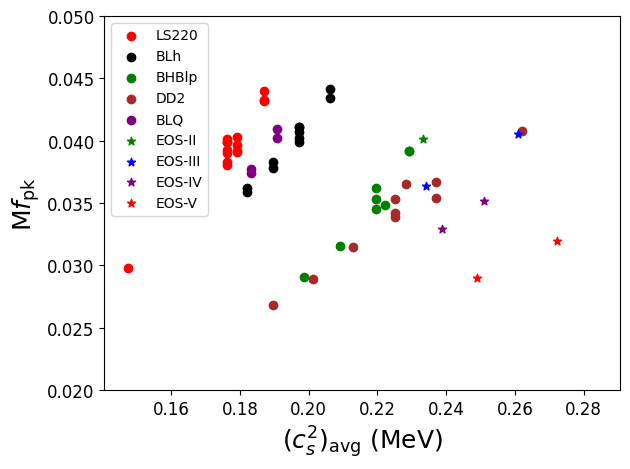

In [101]:
eos_labeled = {}
rvss_labeled = {}
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 18
cs2p_mf2_fig,cs2p_mf2_axes = plt.subplots(1)
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['eos'] not in eos_labeled:
        eos_labeled[sim_info_core_subeos[sim]['eos']] = False
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.02 and not eos_labeled[sim_info_core_subeos[sim]['eos']]:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']],label=sim_info_core_subeos[sim]['eos'])
        eos_labeled[sim_info_core_subeos[sim]['eos']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['model'] not in rvss_labeled:
        rvss_labeled[sim_info_RVSS[sim]['model']] = False
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02 and not rvss_labeled[sim_info_RVSS[sim]['model']]:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2_Vavg'],sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*',label=f"EOS-{sim_info_RVSS[sim]['model']}")
        rvss_labeled[sim_info_RVSS[sim]['model']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2_Vavg'],sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*')

cs2p_mf2_axes.set_ylim([0.02,0.05])
# cs2p_mf2_axes.set_xlim([0.00135,0.0017])

cs2p_mf2_axes.set_ylabel(r"$\text{M}f_{\text{pk}}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.set_xlabel(r"$(c_s^2)_{\text{avg}}~\left(\text{MeV}\right)$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mf2_axes.legend()
#cs2p_mf2_axes.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
#cs2p_mf2_axes.text(x=0.9,y=0.05,s="a)",transform=cs2p_mf2_axes.transAxes,fontsize=text_fontsize)
cs2p_mf2_fig.tight_layout()
# cs2p_mf2_fig.savefig('./Figures/Final_Paper_Figs/Mfpk_cs2p_core_RVSS.pdf',format='pdf',dpi=300)






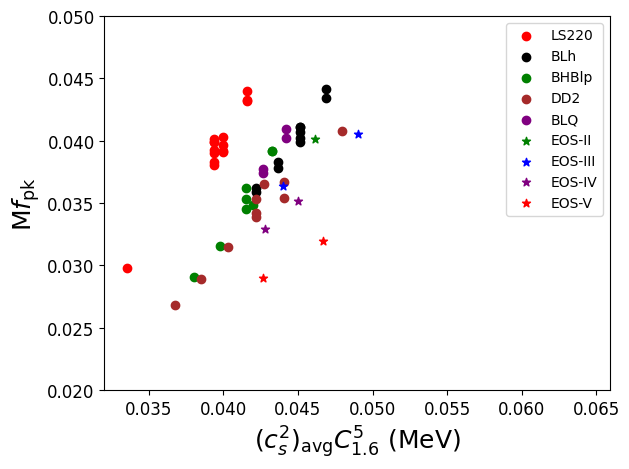

In [34]:
eos_labeled = {}
rvss_labeled = {}
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 18
cs2p_mf2_fig,cs2p_mf2_axes = plt.subplots(1)
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['eos'] not in eos_labeled:
        eos_labeled[sim_info_core_subeos[sim]['eos']] = False
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.02 and not eos_labeled[sim_info_core_subeos[sim]['eos']]:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2_Vavg']*sim_info_core_subeos[sim]['C1p6'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']],label=sim_info_core_subeos[sim]['eos'])
        eos_labeled[sim_info_core_subeos[sim]['eos']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2_Vavg']*sim_info_core_subeos[sim]['C1p6'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['model'] not in rvss_labeled:
        rvss_labeled[sim_info_RVSS[sim]['model']] = False
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02 and not rvss_labeled[sim_info_RVSS[sim]['model']]:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2_Vavg']*sim_info_RVSS[sim]['C_1p6'],sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*',label=f"EOS-{sim_info_RVSS[sim]['model']}")
        rvss_labeled[sim_info_RVSS[sim]['model']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2_Vavg']*sim_info_RVSS[sim]['C_1p6'],sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*')

cs2p_mf2_axes.set_ylim([0.02,0.05])
#cs2p_mf2_axes.set_xlim([0.00004,0.00008])

cs2p_mf2_axes.set_ylabel(r"$\text{M}f_{\text{pk}}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.set_xlabel(r"$(c_s^2)_{\text{avg}}C_{1.6}^5~\left(\text{MeV}\right)$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mf2_axes.legend()
#cs2p_mf2_axes.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
#cs2p_mf2_axes.text(x=0.9,y=0.05,s="a)",transform=cs2p_mf2_axes.transAxes,fontsize=text_fontsize)
cs2p_mf2_fig.tight_layout()
# cs2p_mf2_fig.savefig('./Figures/Final_Paper_Figs/Mfpk_cs2p_core_RVSS.pdf',format='pdf',dpi=300)






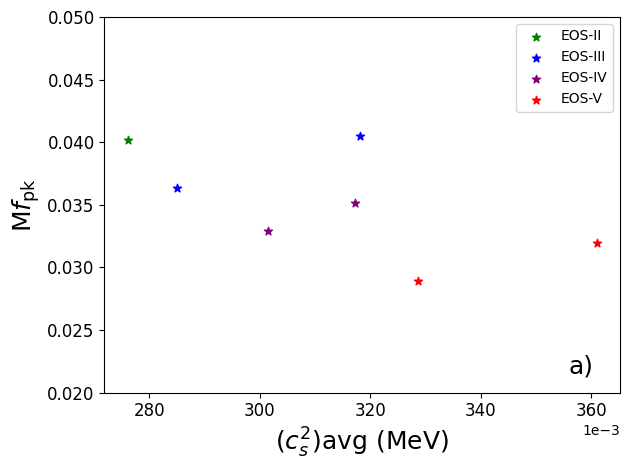

In [37]:
eos_labeled = {}
rvss_labeled = {}
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 18
cs2p_mf2_fig,cs2p_mf2_axes = plt.subplots(1)
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['eos'] not in eos_labeled:
        eos_labeled[sim_info_core_subeos[sim]['eos']] = False
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.02 and not eos_labeled[sim_info_core_subeos[sim]['eos']]:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']],label=sim_info_core_subeos[sim]['eos'])
        eos_labeled[sim_info_core_subeos[sim]['eos']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['model'] not in rvss_labeled:
        rvss_labeled[sim_info_RVSS[sim]['model']] = False
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02 and not rvss_labeled[sim_info_RVSS[sim]['model']]:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2_Vavg'],sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*',label=f"EOS-{sim_info_RVSS[sim]['model']}")
        rvss_labeled[sim_info_RVSS[sim]['model']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2_Vavg'],sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*')

cs2p_mf2_axes.set_ylim([0.02,0.05])
# cs2p_mf2_axes.set_xlim([0.00135,0.0017])

cs2p_mf2_axes.set_ylabel(r"$\text{M}f_{\text{pk}}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.set_xlabel(r"$(c_s^2){\text{avg}}~\left(\text{MeV}\right)$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mf2_axes.legend()
cs2p_mf2_axes.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
cs2p_mf2_axes.text(x=0.9,y=0.05,s="a)",transform=cs2p_mf2_axes.transAxes,fontsize=text_fontsize)
cs2p_mf2_fig.tight_layout()
# cs2p_mf2_fig.savefig('./Figures/Final_Paper_Figs/Mfpk_cs2p_core_RVSS.pdf',format='pdf',dpi=300)






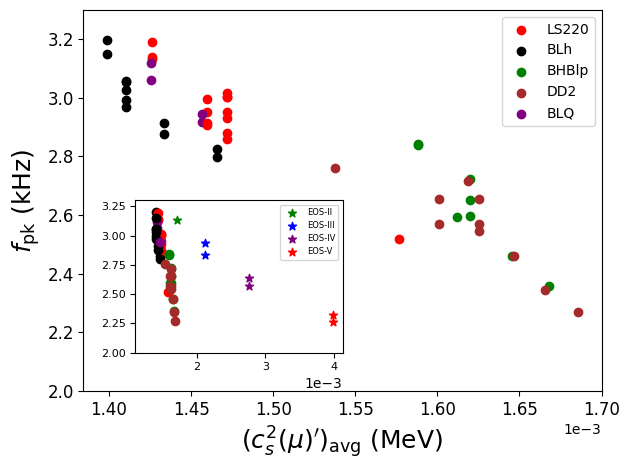

In [43]:
eos_labeled = {}
rvss_labeled = {}
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 18
cs2p_mf2_fig,cs2p_mf2_axes = plt.subplots(1)
cs2p_mf2_inset_ax = cs2p_mf2_axes.inset_axes([0.1,0.1,0.4,0.4],transform=cs2p_mf2_axes.transAxes)

for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['eos'] not in eos_labeled:
        eos_labeled[sim_info_core_subeos[sim]['eos']] = False
    if sim_info_core_subeos[sim]['fpeak'] > 2.0 and not eos_labeled[sim_info_core_subeos[sim]['eos']]:
        cs2p_mf2_inset_ax.scatter(sim_info_core_subeos[sim]['cs2p_Vavg'],sim_info_core_subeos[sim]['fpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg'],sim_info_core_subeos[sim]['fpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']],label=sim_info_core_subeos[sim]['eos'])
        eos_labeled[sim_info_core_subeos[sim]['eos']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg'],sim_info_core_subeos[sim]['fpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])
        cs2p_mf2_inset_ax.scatter(sim_info_core_subeos[sim]['cs2p_Vavg'],sim_info_core_subeos[sim]['fpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])
        


for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['model'] not in rvss_labeled:
        rvss_labeled[sim_info_RVSS[sim]['model']] = False
    if sim_info_RVSS[sim]['fpeak'] > 2.0 and not rvss_labeled[sim_info_RVSS[sim]['model']]:
        # cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg'],sim_info_RVSS[sim]['fpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*',label=f"EOS-{sim_info_RVSS[sim]['model']}")
        rvss_labeled[sim_info_RVSS[sim]['model']] = True
        cs2p_mf2_inset_ax.scatter(sim_info_RVSS[sim]['cs2p_Vavg'],sim_info_RVSS[sim]['fpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*',label=f"EOS-{sim_info_RVSS[sim]['model']}")

    else:
        # cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg'],sim_info_RVSS[sim]['fpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*')
        cs2p_mf2_inset_ax.scatter(sim_info_RVSS[sim]['cs2p_Vavg'],sim_info_RVSS[sim]['fpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*')

cs2p_mf2_axes.set_ylim([2.0,3.3])


#cs2p_mf2_axes.set_xlim([0.00135,0.0017])

cs2p_mf2_axes.set_ylabel(r"$f_{\text{pk}}\text{ (kHz)}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}~\left(\text{MeV}\right)$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mf2_axes.legend()
cs2p_mf2_axes.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
cs2p_mf2_fig.tight_layout()

cs2p_mf2_inset_ax.tick_params(labelsize=8)
cs2p_mf2_inset_ax.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
cs2p_mf2_inset_ax.set_ylim([2.0,3.3])
cs2p_mf2_inset_ax.legend(fontsize=6)
cs2p_mf2_fig.tight_layout()
cs2p_mf2_fig.savefig('./Figures/Final_Paper_Figs/fpk_cs2p_CORE.pdf',format='pdf',dpi=300)






CoRe
RVSS


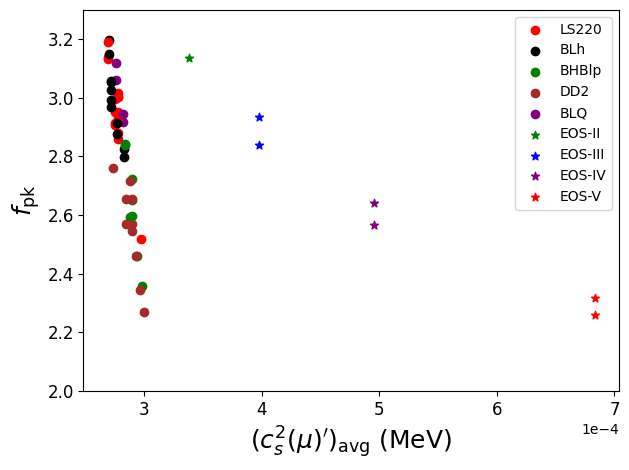

In [53]:
eos_labeled = {}
rvss_labeled = {}
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 18
cs2p_mf2_fig,cs2p_mf2_axes = plt.subplots(1)
print('CoRe')
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['eos'] not in eos_labeled:
        eos_labeled[sim_info_core_subeos[sim]['eos']] = False
    if sim_info_core_subeos[sim]['fpeak'] > 2.0 and not eos_labeled[sim_info_core_subeos[sim]['eos']]:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg']*sim_info_core_subeos[sim]['C1p6'],sim_info_core_subeos[sim]['fpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']],label=sim_info_core_subeos[sim]['eos'])
        eos_labeled[sim_info_core_subeos[sim]['eos']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg']*sim_info_core_subeos[sim]['C1p6'],sim_info_core_subeos[sim]['fpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])
print('RVSS')
for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['model'] not in rvss_labeled:
        rvss_labeled[sim_info_RVSS[sim]['model']] = False
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02 and not rvss_labeled[sim_info_RVSS[sim]['model']]:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg']*sim_info_RVSS[sim]['C_1p6'],sim_info_RVSS[sim]['fpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*',label=f"EOS-{sim_info_RVSS[sim]['model']}")
        rvss_labeled[sim_info_RVSS[sim]['model']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg']*sim_info_RVSS[sim]['C_1p6'],sim_info_RVSS[sim]['fpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*')

cs2p_mf2_axes.set_ylim([2.0,3.3])
#cs2p_mf2_axes.set_xlim([0.000260,0.000310])

cs2p_mf2_axes.set_ylabel(r"$f_{\text{pk}}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}~\left(\text{MeV}\right)$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mf2_axes.legend()
cs2p_mf2_axes.ticklabel_format(style='sci',axis='x',scilimits=(-4,-4))
cs2p_mf2_fig.tight_layout()
# cs2p_mf2_fig.savefig('./Figures/Final_Paper_Figs/Mfpk_cs2p_core_RVSS.pdf',format='pdf',dpi=300)






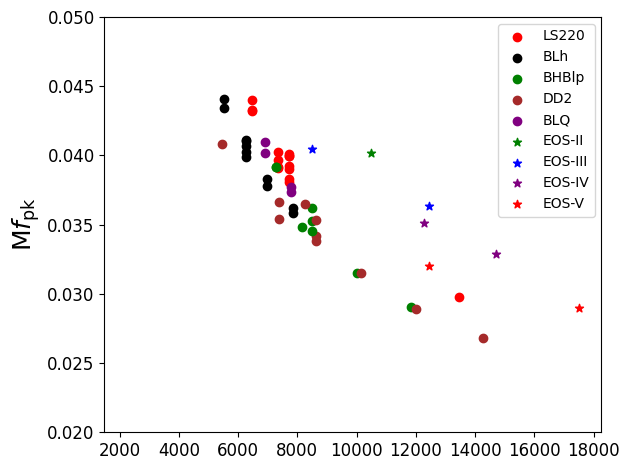

In [32]:
eos_labeled = {}
rvss_labeled = {}
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16
cs2p_mf2_fig,cs2p_mf2_axes = plt.subplots(1)
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['eos'] not in eos_labeled:
        eos_labeled[sim_info_core_subeos[sim]['eos']] = False
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.02 and not eos_labeled[sim_info_core_subeos[sim]['eos']]:
        cs2p_mf2_axes.scatter((sim_info[sim]['C']**(-5.0)),sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']],label=sim_info_core_subeos[sim]['eos'])
        eos_labeled[sim_info_core_subeos[sim]['eos']] = True
    else:
        cs2p_mf2_axes.scatter((sim_info[sim]['C']**(-5.0)),sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['model'] not in rvss_labeled:
        rvss_labeled[sim_info_RVSS[sim]['model']] = False
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02 and not rvss_labeled[sim_info_RVSS[sim]['model']]:
        cs2p_mf2_axes.scatter((sim_info_RVSS[sim]['C']**(-5.0)),sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*',label=f"EOS-{sim_info_RVSS[sim]['model']}")
        rvss_labeled[sim_info_RVSS[sim]['model']] = True
    else:
        cs2p_mf2_axes.scatter((sim_info_RVSS[sim]['C']**(-5.0)),sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*')

cs2p_mf2_axes.set_ylim([0.02,0.05])
#cs2p_mf2_axes.set_xlim([0.00135,0.0017])

cs2p_mf2_axes.set_ylabel(r"$\text{M}f_{\text{pk}}$",fontsize=axes_label_fontsize)
#cs2p_mf2_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}C^{-5}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mf2_axes.legend()
#cs2p_mf2_axes.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
cs2p_mf2_fig.tight_layout()
# cs2p_mf2_fig.savefig('./Figures/Final_Paper_Figs/Mfpk_cs2p_Cm5_core.pdf',format='pdf',dpi=300)






In [29]:
for eos in core_mvr_data:
    print(eos,np.max(eos_cs2[eos]))

BLh 0.998001
DD2F 0.7768295315195575
DD2F-SF1 0.998001
LS220 0.9044673941218184
BHBlp 0.6073097390973933
DD2 0.9491597535294344
SLy4 0.9801
BA 0.7277591357500164
BLQ 0.6793305233065974
SFHo 0.9497602993846341


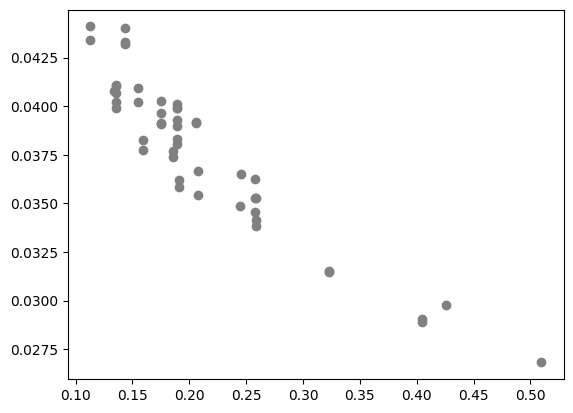

In [44]:
simulations_for_fit = {}
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.02:
        plt.scatter(sim_info_core_subeos[sim]['cs2p_Vavg']*sim_info[sim]['kappa_2T'],sim_info[sim]['Mfpeak'],color='gray')
        simulations_for_fit[sim] = sim_info_core_subeos[sim]

In [45]:
k2T_cs2_mub_list = np.linspace(0,0.06,200)
k2T_list = np.linspace(50,400,200)
k2T_cs2p_list = np.linspace(0.10,0.50,200)
Cm5_list = np.linspace(4000,15000,200)
Cm5_cs2p_list = np.linspace(0,50,200)
C1p6_cs2p_list = np.linspace(0.00025,0.00035,200)
cs2p_list = np.linspace(0.001,0.0025,100)

In [46]:
fpk_fit = np.asarray([sim_info[sim]['fpeak'] for sim in simulations_for_fit])
k2T_cs2p_vavg_fit= np.asarray([sim_info[sim]['kappa_2T']*sim_info_core_subeos[sim]['cs2p_Vavg'] for sim in simulations_for_fit])
Cm5_cs2p_vavg_fit= np.asarray([sim_info_core_subeos[sim]['cs2p_Vavg']*(sim_info[sim]['C'])**(-5.0) for sim in simulations_for_fit])
Cm5_vavg_fit= np.asarray([(sim_info[sim]['C'])**(-5.0) for sim in simulations_for_fit])
cs2p_C1p6_vavg_fit = np.asarray([(sim_info_core_subeos[sim]['C1p6'] * sim_info_core_subeos[sim]['cs2p_Vavg']) for sim in simulations_for_fit])

cs2p_vavg_fit = np.asarray([sim_info_core_subeos[sim]['cs2p_Vavg'] for sim in simulations_for_fit])

cs2p_C1p4_vavg_fit = np.asarray([(sim_info_core_subeos[sim]['C1p4'] * sim_info_core_subeos[sim]['cs2p_Vavg']) for sim in simulations_for_fit])

In [47]:
def lin_model(x,m,b):
    return m*x + b

In [46]:
popt_C1p4_cs2p, pcov_C1p4_cs2p = curve_fit(lin_model, cs2p_C1p4_vavg_fit, fpk_fit)
a0_1p4, a1_1p4 = popt_C1p4_cs2p
mf2_pred = lin_model(cs2p_C1p4_vavg_fit, a0_1p4, a1_1p4)
r2_C1p4_cs2p = r2_score(fpk_fit, mf2_pred)
print(r2_C1p4_cs2p)
print(popt_C1p4_cs2p)

0.9076343145415526
[-2.55106640e+04  9.04449908e+00]


In [66]:
popt_C1p6_cs2p, pcov_C1p6_cs2p = curve_fit(lin_model, cs2p_vavg_fit, fpk_fit)
a0, a1 = popt_C1p6_cs2p
mf2_pred = lin_model(cs2p_vavg_fit, a0, a1)
r2_C1p6_cs2p = r2_score(fpk_fit, mf2_pred)
print(r2_C1p6_cs2p)
print(popt_C1p6_cs2p)

0.8530285752948205
[-2392.53782982     6.45026354]


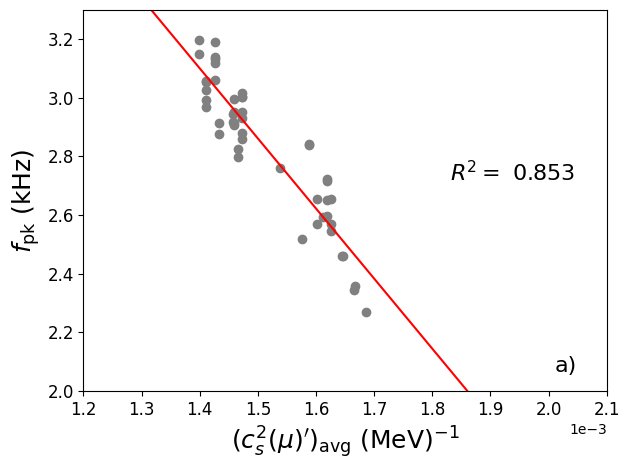

In [75]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16
cs2p_fig,cs2p_axes = plt.subplots(1)

for sim in simulations_for_fit:
    cs2p_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg'],sim_info_core_subeos[sim]['fpeak'],color='grey')

cs2p_axes.plot(cs2p_list,lin_model(cs2p_list,a0,a1),color='red')

cs2p_axes.set_ylim([2.0,3.3])
cs2p_axes.set_xlim([0.0012,0.0021])

cs2p_axes.set_ylabel(r"$f_{\text{pk}}\text{ (kHz)}$",fontsize=axes_label_fontsize)
cs2p_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}~\left(\text{MeV}\right)^{-1}$",fontsize=axes_label_fontsize)
cs2p_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_axes.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
cs2p_axes.text(x=0.7,y=0.55,s=r"$R^2=~0.853$",transform=cs2p_axes.transAxes,fontsize=text_fontsize)
cs2p_axes.text(x=0.9,y=0.05,s=r"a)",transform=cs2p_axes.transAxes,fontsize=text_fontsize)

cs2p_fig.tight_layout()
cs2p_fig.savefig('./Figures/Final_Paper_Figs/fpk_cs2p_core_RVSS.pdf',format='pdf',dpi=300)


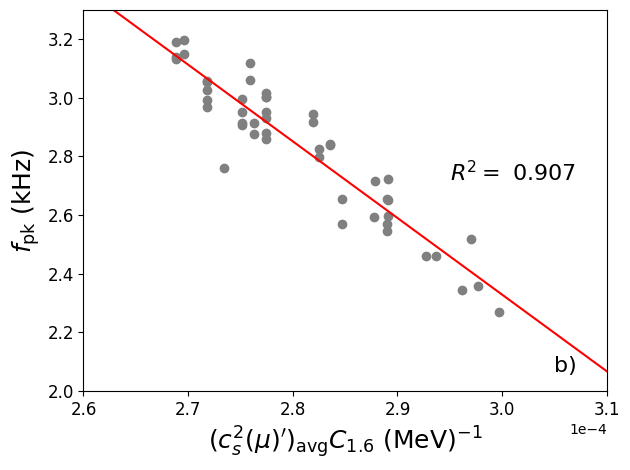

In [60]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16
cs2p_C1p6_fig,cs2p_C1p6_axes = plt.subplots(1)

for sim in simulations_for_fit:
    cs2p_C1p6_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg']*sim_info_core_subeos[sim]['C1p6'],sim_info_core_subeos[sim]['fpeak'],color='grey')

cs2p_C1p6_axes.plot(C1p6_cs2p_list,lin_model(C1p6_cs2p_list,a0_1p6,a1_1p6),color='red')

cs2p_C1p6_axes.set_ylim([2.0,3.3])
cs2p_C1p6_axes.set_xlim([0.000260,0.000310])

cs2p_C1p6_axes.set_ylabel(r"$f_{\text{pk}}\text{ (kHz)}$",fontsize=axes_label_fontsize)
cs2p_C1p6_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}C_{1.6}~\left(\text{MeV}\right)^{-1}$",fontsize=axes_label_fontsize)
cs2p_C1p6_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_C1p6_axes.ticklabel_format(style='sci',axis='x',scilimits=(-4,-4))
cs2p_C1p6_axes.text(x=0.7,y=0.55,s=r"$R^2=~0.907$",transform=cs2p_C1p6_axes.transAxes,fontsize=text_fontsize)
cs2p_C1p6_axes.text(x=0.9,y=0.05,s=r"b)",transform=cs2p_C1p6_axes.transAxes,fontsize=text_fontsize)

cs2p_C1p6_fig.tight_layout()
cs2p_C1p6_fig.savefig('./Figures/Final_Paper_Figs/fpk_cs2p_C1p6_core_RVSS.pdf',format='pdf',dpi=300)


In [50]:
popt_k2t_cs2p,pcov_k2t_cs2p = curve_fit(fit_model,k2T_cs2p_vavg_fit,fpk_fit,(1.0,1.0,1.0,1.0,1.0),maxfev=5000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_cs2p,a1_cs2p,a2_cs2p,a3_cs2p,a4_cs2p = popt_k2t_cs2p
mf2_pred = fit_model(k2T_cs2p_vavg_fit,a0_cs2p,a1_cs2p,a2_cs2p,a3_cs2p,a4_cs2p)
r2_k2t_cs2p = r2_score(fpk_fit,mf2_pred)
print(r2_k2t_cs2p)
print(popt_k2t_cs2p)


0.8390009355785922
[1.69249702e+00 1.86419610e+01 1.25355433e+02 1.99675150e-38
 1.20639014e+02]


In [44]:
popt_Cm5_cs2p,pcov_Cm5_cs2p = curve_fit(fit_model,Cm5_cs2p_vavg_fit,mfpk_fit,(1.0,1.0,1.0,1.0,1.0),maxfev=5000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_C,a1_C,a2_C,a3_C,a4_C = popt_Cm5_cs2p
mf2_pred = fit_model(Cm5_cs2p_vavg_fit,a0_C,a1_C,a2_C,a3_C,a4_C)
r2_C_cs2p = r2_score(mfpk_fit,mf2_pred)
print(r2_C_cs2p)
print(popt_Cm5_cs2p)

0.90227250079632
[2.67257784e-04 5.54191106e+01 1.70226798e+00 2.46024571e-06
 3.83811132e-02]


In [ ]:
popt_Cm5,pcov_Cm5 = curve_fit(fit_model,Cm5_vavg_fit,mfpk_fit,(0.2,3.4,0.0001,10,0.001),maxfev=5000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_C1,a1_C1,a2_C1,a3_C1,a4_C1 = popt_Cm5
mf2_pred = fit_model(Cm5_vavg_fit,a0_C1,a1_C1,a2_C1,a3_C1,a4_C1)
r2_Cm5= r2_score(fpk_fit,mf2_pred)
print(r2_Cm5)
print(popt_Cm5)

0.8631435255068893
[1.47402830e-01 3.87286826e+00 2.03333116e-12 7.76116316e+00
 9.60585374e-04]


In [48]:
k2T = []
k2T_cs2mub = []
f2 = []

k2T_Rvss = []
k2T_cs2mub_rvss = []
Mf2_rvss = []

for sim in sim_info_RVSS:
    
    # k2T.append(sim_info_RVSS[sim]['kappa_2T'])
    # Mf2.append(sim_info_RVSS[sim]['Mfpeak'])
    # k2T_cs2mub.append(sim_info_RVSS[sim]['kappa_2T']*sim_info_RVSS[sim]['cs2_mub_vavg'])
    k2T_Rvss.append(sim_info_RVSS[sim]['kappa_2T'])
    Mf2_rvss.append(sim_info_RVSS[sim]["fpeak"])
    k2T_cs2mub_rvss.append(sim_info_RVSS[sim]['kappa_2T']*sim_info_RVSS[sim]['cs2_mub_vavg'])

for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.020:
        k2T.append(sim_info_core_subeos[sim]['kappa_2T'])
        f2.append(sim_info_core_subeos[sim]["fpeak"])
        #k2T_cs2mub.append(sim_info_core_subeos[sim]['kappa_2T']*sim_info_core_subeos[sim]['cs2mub_Vavg'])

        


k2T = np.asarray(k2T)
k2T_cs2mub = np.asanyarray(k2T_cs2mub)
f2 = np.asanyarray(f2)

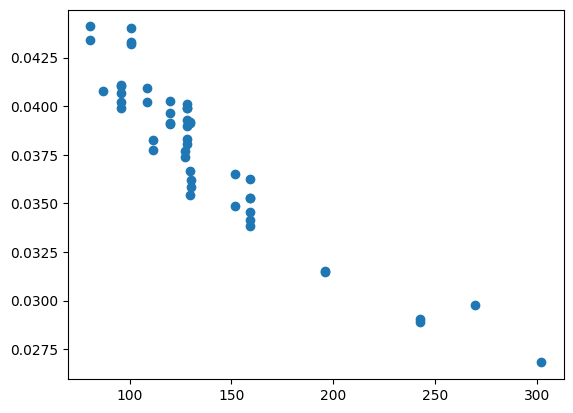

In [126]:
plt.scatter(k2T,Mf2)

In [49]:
popt_k2t,pcov_k2t = curve_fit(fit_model,k2T,f2,(1.0,1.0,1.0,1.0,1.0),maxfev=5000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0,a1,a2,a3,a4 = popt_k2t
mf2_pred = fit_model(k2T,a0,a1,a2,a3,a4)
print(popt_k2t)
r2_k2t = r2_score(f2,mf2_pred)
print(r2_k2t)

[8.37059565e-03 1.11804171e+01 8.32515257e-02 5.76987172e-36
 4.39135540e-04]
0.7900142204675024


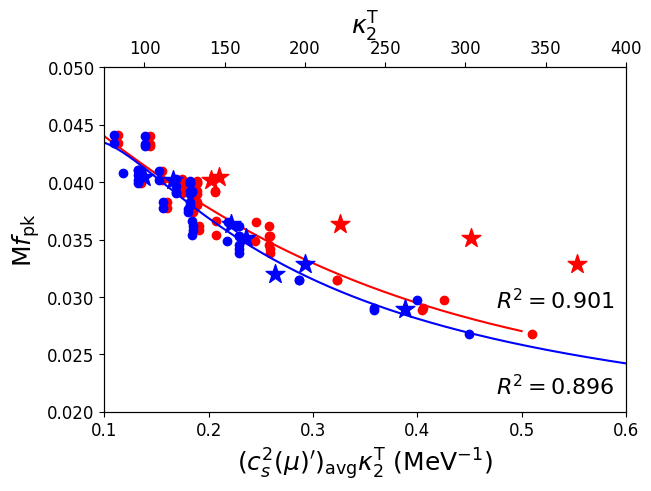

In [74]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16

kappa2T_cs2p_fig,kappa2T_cs2p_axes = plt.subplots(1,layout='constrained')
kappa2T_cs2p_axes.plot(k2T_cs2p_list,fit_model(k2T_cs2p_list,a0_cs2p,a1_cs2p,a2_cs2p,a3_cs2p,a4_cs2p),color='red')
kappa2T_cs2p_axes.scatter(k2T_cs2p_vavg_fit,mfpk_fit,color='red')
kappa2T_cs2p_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}\kappa_2^{\text{T}} \text{ (MeV}^{-1})$",fontsize=axes_label_fontsize)
kappa2T_cs2p_axes.set_ylabel(r'$\text{M}f_{\text{pk}}$',fontsize=axes_label_fontsize)
kappa2T_cs2p_axes.set_xlim([0.1,0.6])
kappa2T_cs2p_axes.set_ylim([0.02,0.05])
kappa2T_cs2p_axes.text(0.75,0.3,r"$R^2 = 0.901$",transform=kappa2T_cs2p_axes.transAxes,fontsize=text_fontsize)
kappa2T_cs2p_axes.tick_params(labelsize=tick_label_fontsize)

for sim in sim_info_RVSS:
    kappa2T_cs2p_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg']*sim_info_RVSS[sim]['kappa_2T'],sim_info_RVSS[sim]['Mfpeak'],marker='*',color='red',s=200)


k2T_mf2_axes = kappa2T_cs2p_axes.twiny()


for sim in sim_info_RVSS:
    k2T_mf2_axes.scatter(sim_info_RVSS[sim]['kappa_2T'],sim_info_RVSS[sim]['Mfpeak'],marker='*',color='blue',s=200)

k2T_mf2_axes.scatter(k2T,Mf2,color='blue')
k2T_mf2_axes.scatter(k2T_Rvss,Mf2_rvss,marker='*',s=125,color='blue')
k2T_mf2_axes.plot(k2T_list,fit_model(k2T_list,a0,a1,a2,a3,a4),color='blue')

k2T_mf2_axes.set_xlabel(r'$\kappa_2^{\text{T}}$',fontsize=axes_label_fontsize)
k2T_mf2_axes.set_ylabel(r'$\text{M}f_{\text{pk}}$',fontsize=axes_label_fontsize)
k2T_mf2_axes.set_xlim([75,400])
k2T_mf2_axes.set_ylim([0.02,0.05])
k2T_mf2_axes.text(0.75,0.05,r"$R^2 = 0.896$",transform=k2T_mf2_axes.transAxes,fontsize=text_fontsize)
k2T_mf2_axes.tick_params(labelsize=tick_label_fontsize)

kappa2T_cs2p_fig.savefig("./Figures/Final_Paper_Figs/Mfpk_k2Tcs2p_vavg_k2T.pdf",format='pdf',dpi=300)



/tmp/ipykernel_10993/2411968152.py:19: UserWarning: The figure layout has changed to tight
  Cm5_cs2p_fig.tight_layout()


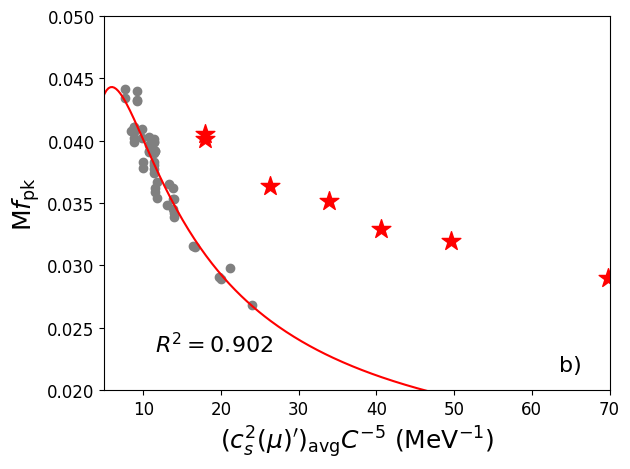

In [ ]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16

Cm5_cs2p_fig,Cm5_cs2p_axes = plt.subplots(1,layout='constrained')
Cm5_cs2p_axes.plot(Cm5_cs2p_list,fit_model(Cm5_cs2p_list,a0_C,a1_C,a2_C,a3_C,a4_C),color='red')
Cm5_cs2p_axes.scatter(Cm5_cs2p_vavg_fit,mfpk_fit,color='grey')
Cm5_cs2p_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}C^{-5} \text{ (MeV}^{-1})$",fontsize=axes_label_fontsize)
Cm5_cs2p_axes.set_ylabel(r'$\text{M}f_{\text{pk}}$',fontsize=axes_label_fontsize)
Cm5_cs2p_axes.set_xlim([5,70])
Cm5_cs2p_axes.set_ylim([0.02,0.05])
Cm5_cs2p_axes.text(0.1,0.1,r"$R^2 = 0.902$",transform=Cm5_cs2p_axes.transAxes,fontsize=text_fontsize)
Cm5_cs2p_axes.tick_params(labelsize=tick_label_fontsize)

for sim in sim_info_RVSS:
    Cm5_cs2p_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg']*sim_info_RVSS[sim]['C']**(-5.0),sim_info_RVSS[sim]['Mfpeak'],marker='*',color='red',s=200)
Cm5_cs2p_axes.text(x=0.9,y=0.05,s="b)",transform=Cm5_cs2p_axes.transAxes,fontsize=text_fontsize)

Cm5_cs2p_fig.tight_layout()
# Cm5_cs2p_fig.savefig("./Figures/Final_Paper_Figs/Mfpk_Cm5.pdf",format='pdf',dpi=300)



/tmp/ipykernel_10993/3712339482.py:32: UserWarning: The figure layout has changed to tight
  Cm5_cs2p_fig.tight_layout()


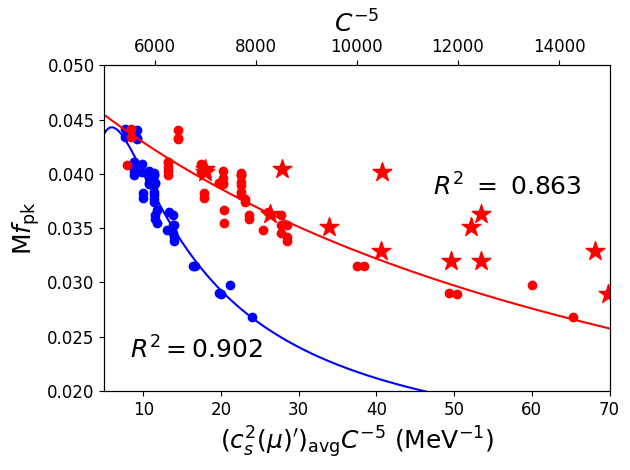

In [72]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 18

Cm5_cs2p_fig,Cm5_cs2p_axes = plt.subplots(1,layout='constrained')
Cm5_cs2p_axes.plot(Cm5_cs2p_list,fit_model(Cm5_cs2p_list,a0_C,a1_C,a2_C,a3_C,a4_C),color='blue')
Cm5_cs2p_axes.scatter(Cm5_cs2p_vavg_fit,mfpk_fit,color='blue')
Cm5_cs2p_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}C^{-5} \text{ (MeV}^{-1})$",fontsize=axes_label_fontsize)
Cm5_cs2p_axes.set_ylabel(r'$\text{M}f_{\text{pk}}$',fontsize=axes_label_fontsize)
Cm5_cs2p_axes.set_xlim([5,70])
Cm5_cs2p_axes.set_ylim([0.02,0.05])
Cm5_cs2p_axes.text(0.05,0.1,r"$R^2 = 0.902$",transform=Cm5_cs2p_axes.transAxes,fontsize=text_fontsize)
Cm5_cs2p_axes.tick_params(labelsize=tick_label_fontsize)

for sim in sim_info_RVSS:
    Cm5_cs2p_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg']*sim_info_RVSS[sim]['C']**(-5.0),sim_info_RVSS[sim]['Mfpeak'],marker='*',color='red',s=200)
Cm5_cs2p_axes.text(x=0.65,y=0.6,s=r"$R^2~=~0.863$",transform=Cm5_cs2p_axes.transAxes,fontsize=text_fontsize)

Cm5_axes = Cm5_cs2p_axes.twiny()
Cm5_axes.plot(Cm5_list,fit_model(Cm5_list,a0_C1,a1_C1,a2_C1,a3_C1,a4_C1),color='red')
Cm5_axes.scatter(Cm5_vavg_fit,mfpk_fit,color='red')
Cm5_axes.set_xlabel(r"$C^{-5}$",fontsize=axes_label_fontsize)
Cm5_axes.set_ylabel(r'$\text{M}f_{\text{pk}}$',fontsize=axes_label_fontsize)
Cm5_axes.set_xlim([5000,15000])
Cm5_axes.set_ylim([0.02,0.05])
#Cm5_cs2p_axes.text(0.1,0.1,r"$R^2 = 0.902$",transform=Cm5_cs2p_axes.transAxes,fontsize=text_fontsize)
Cm5_axes.tick_params(labelsize=tick_label_fontsize)

for sim in sim_info_RVSS:
    Cm5_axes.scatter(sim_info_RVSS[sim]['C']**(-5.0),sim_info_RVSS[sim]['Mfpeak'],marker='*',color='red',s=200)

Cm5_cs2p_fig.tight_layout()
Cm5_cs2p_fig.savefig("./Figures/Final_Paper_Figs/Mfpk_Cm5_Cm5cs2p.pdf",format='pdf',dpi=300)

